In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from modules.finance.exploration import *
from modules.index.visualisation import plot_indices_with_returns

plt.rcParams.update({"font.size": 14})
pd.set_option("display.max_columns", None)

In [2]:
# Configuration
DATA_DIR = "./data/"
OUTPUT_DIR = "./data/fm_prelim/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Files
FINANCIAL_PANEL_FILE = DATA_DIR + "financial_returns_and_controls.parquet"
EPI_DATA_FILE = DATA_DIR + "epi_data_all_lownull.json"

# Parameters
ROLLING_WINDOW = 14
MAX_LAG = 10
IC = 'aic'
ALPHA = 0.05
CORRECTION_METHOD = 'fdr_bh'

print("✓ Configuration complete")

✓ Configuration complete


## Load Data

In [3]:
# Load data
df_returns = pd.read_parquet(FINANCIAL_PANEL_FILE)
df_epi = pd.read_json(EPI_DATA_FILE)
df_epi['date'] = pd.to_datetime(df_epi['date'])
df_epi = df_epi.set_index('date')

df = df_returns.join(df_epi, how='left')
df[df_epi.columns] = df[df_epi.columns].fillna(0)

print(f"Data loaded: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")

Data loaded: (104, 152)
Date range: 2025-01-07 00:00:00 to 2025-05-30 00:00:00


In [4]:
# Find CCD variants
ccd_variants = find_index_variants(df.columns, 'ccd')
ASSET_COLS = [
    'r_btc', 'r_gold', 'r_spx', 
    'r_spx_auto', 'r_spx_oilgas', 'r_spx_mach', 'r_spx_elec', 
    'r_aapl'
]
ASSET_COLS = [c for c in ASSET_COLS if c in df.columns]

print(f"\nCCD variants found: {len(ccd_variants)}")
for i, var in enumerate(ccd_variants, 1):
    print(f"  {i}. {var}")
print(f"\nAssets: {ASSET_COLS}")


CCD variants found: 4
  1. ccd
  2. ccd_engweighted
  3. ccd_topicweighted
  4. ccd_engweighted_topicweighted

Assets: ['r_btc', 'r_gold', 'r_spx', 'r_spx_auto', 'r_spx_oilgas', 'r_spx_mach', 'r_spx_elec', 'r_aapl']


## Descriptive Statistics


Descriptive Statistics

CCD Variants


,count,mean,std,min,25%,50%,75%,max,skew,kurt,missing_pct,zero_pct
ccd,104.0,0.133283,0.101536,0.001404,0.063346,0.111927,0.169932,0.478513,1.102355,0.975639,0.0,0.000000
ccd_engweighted,104.0,0.127193,0.099550,0.003748,0.059063,0.103849,0.160064,0.472078,1.271902,1.327665,0.0,0.000000
ccd_engweighted_topicweighted,104.0,0.082363,0.062404,0.000000,0.035104,0.071357,0.130662,0.264471,0.574038,-0.375489,0.0,6.730769
ccd_topicweighted,104.0,0.118291,0.082569,0.000000,0.060380,0.117637,0.157102,0.348601,0.445005,-0.379001,0.0,4.807692



Correlation between variants:


,ccd,ccd_engweighted,ccd_topicweighted,ccd_engweighted_topicweighted
ccd,1.000000,0.978065,0.525654,-0.046471
ccd_engweighted,0.978065,1.000000,0.488080,-0.030524
ccd_topicweighted,0.525654,0.488080,1.000000,-0.095760
ccd_engweighted_topicweighted,-0.046471,-0.030524,-0.095760,1.000000


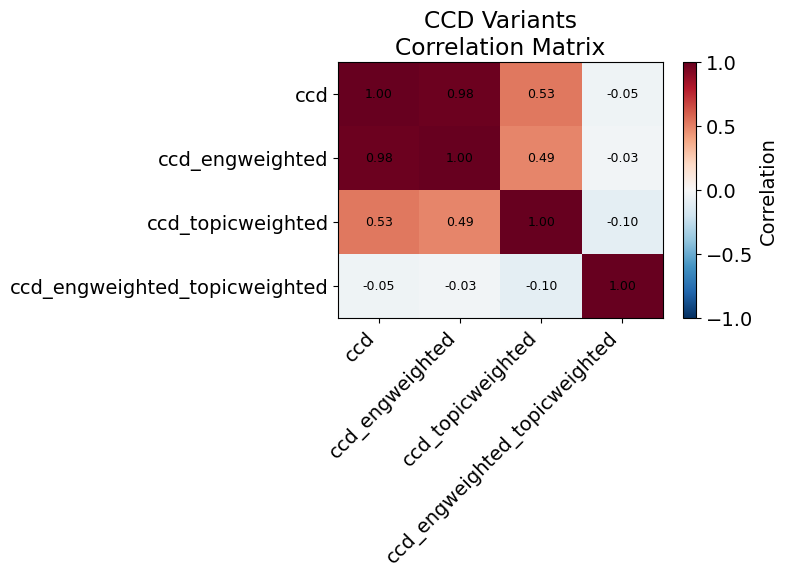

In [5]:
print("\n" + "="*70)
print("Descriptive Statistics")
print("="*70)
stats = compare_index_variants_descriptive(df, ccd_variants, 'CCD Variants')

## Time Series Visualization


Time Series Visualization


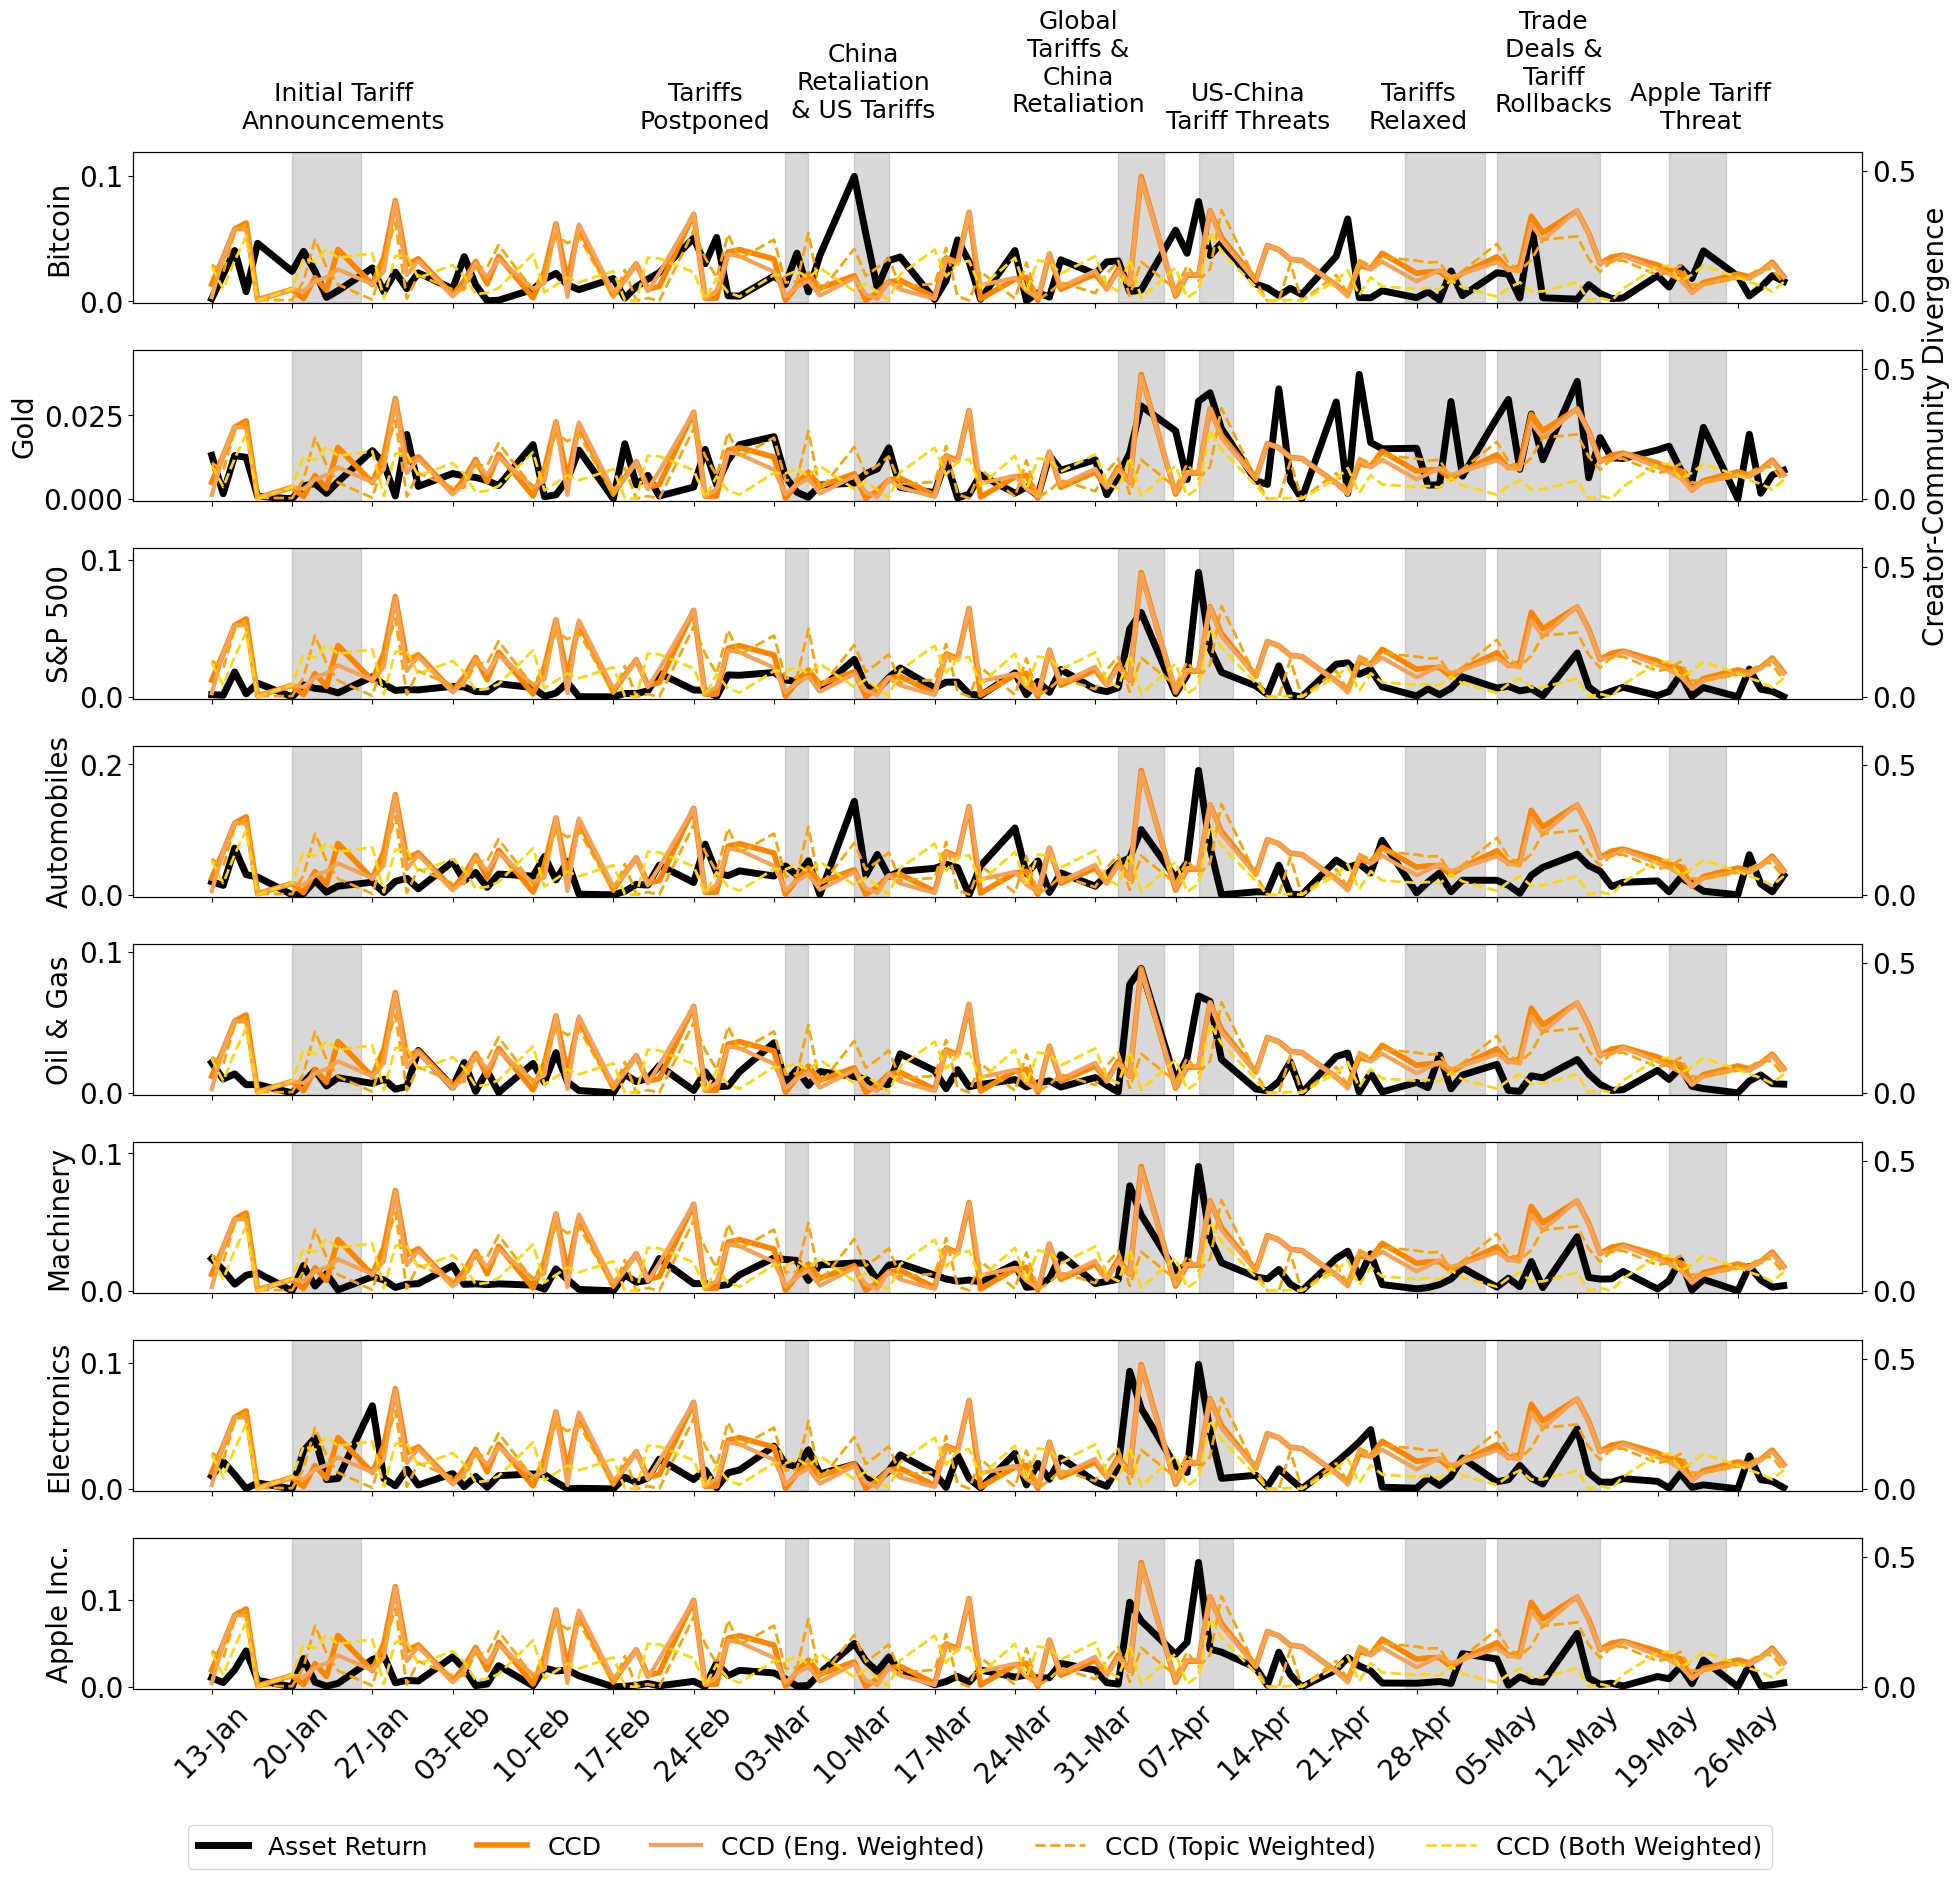

In [6]:
print("\n" + "="*70)
print("Time Series Visualization")
print("="*70)
plot_indices_with_returns(df, index_type='ccd', include_variants=ccd_variants, add_events=True)

## Rolling Correlations with Assets


Rolling Correlations with Assets


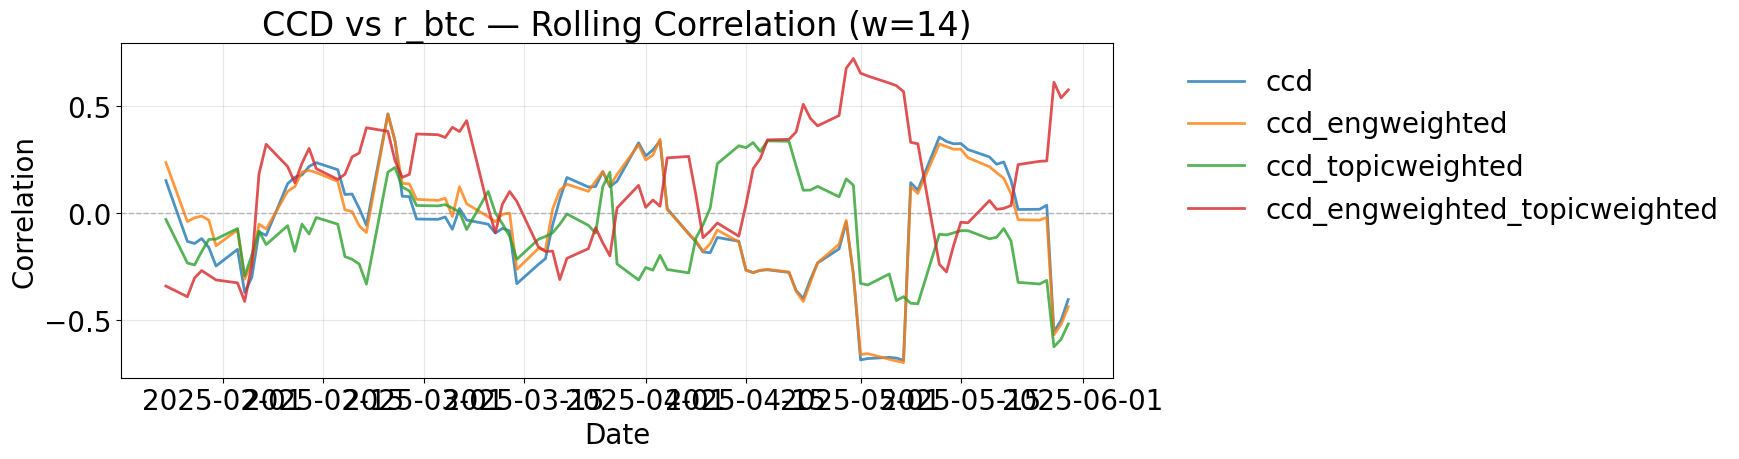

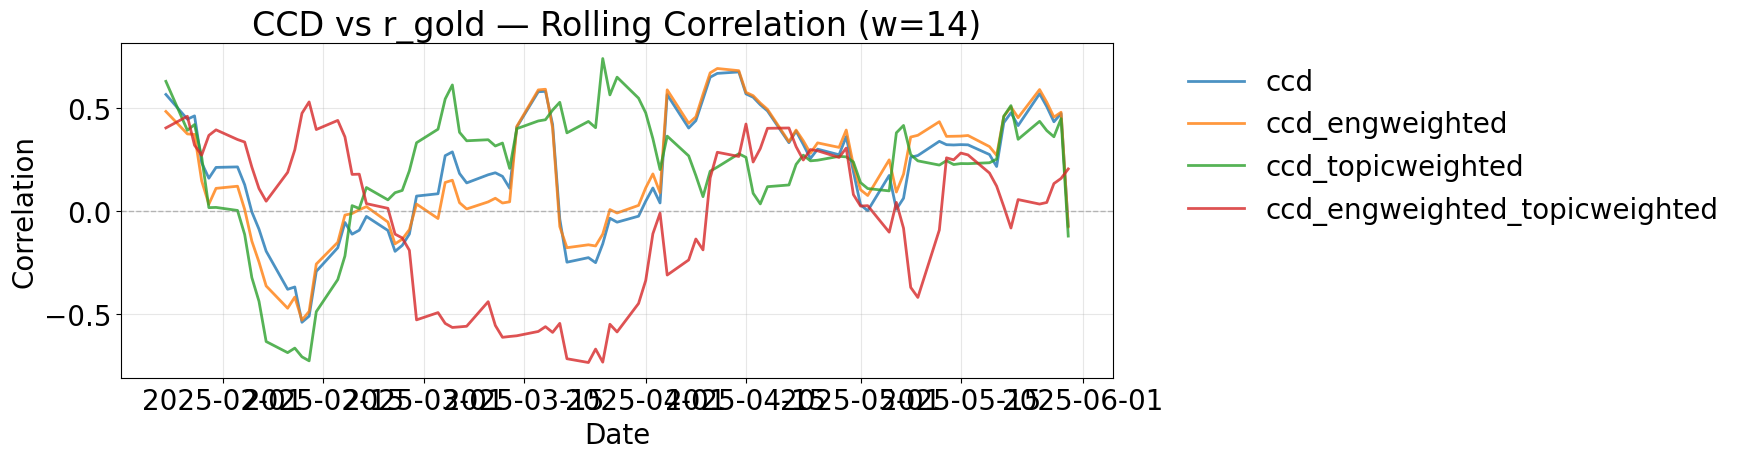

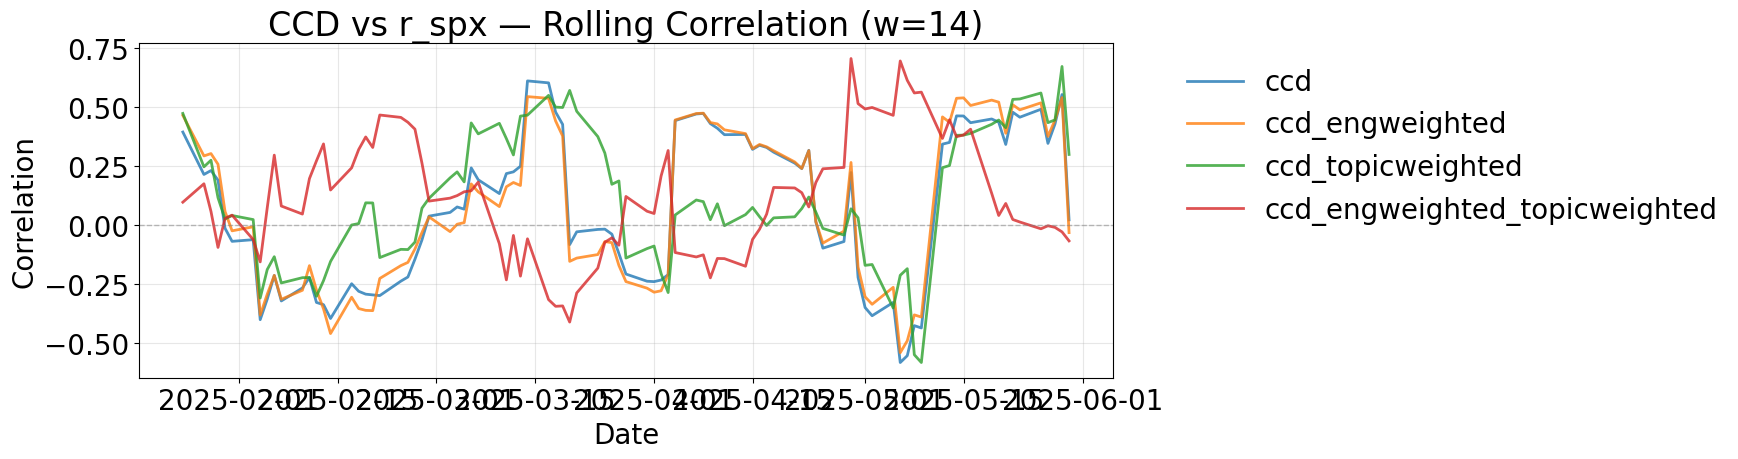

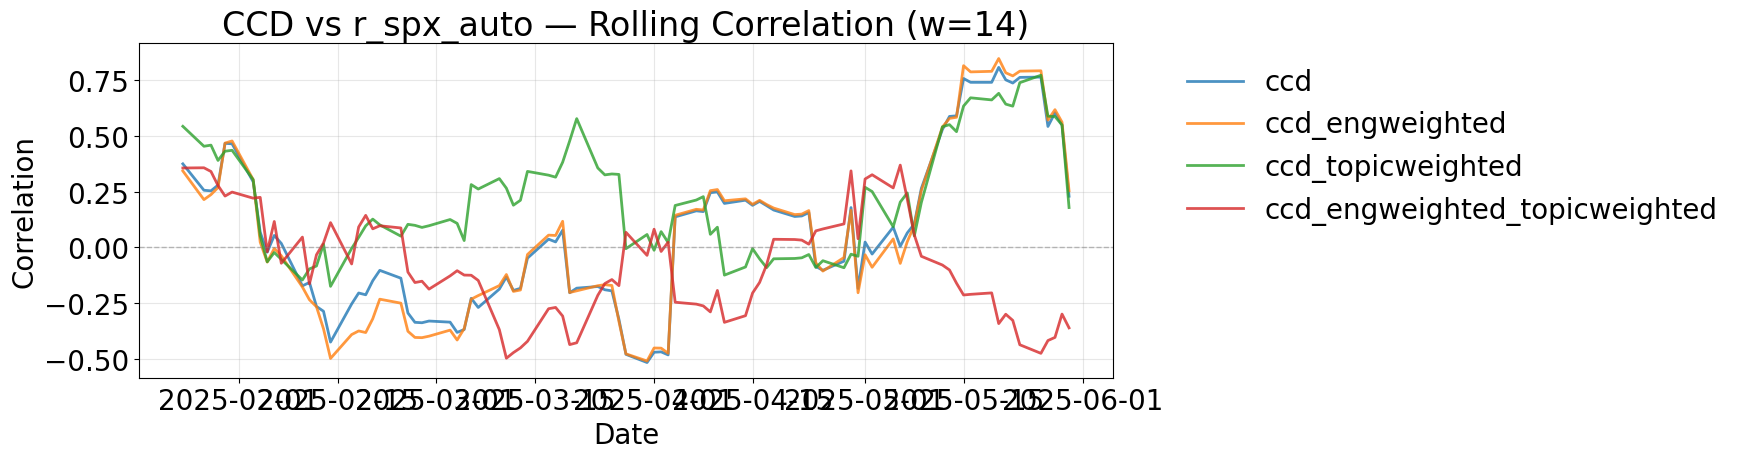

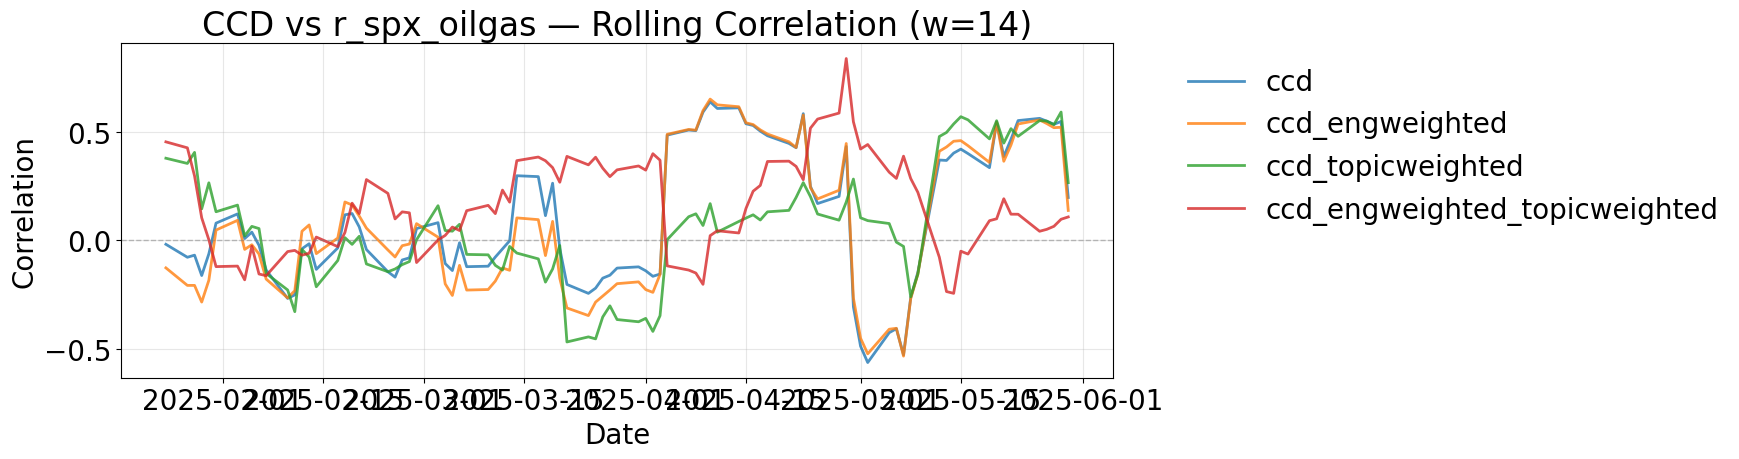

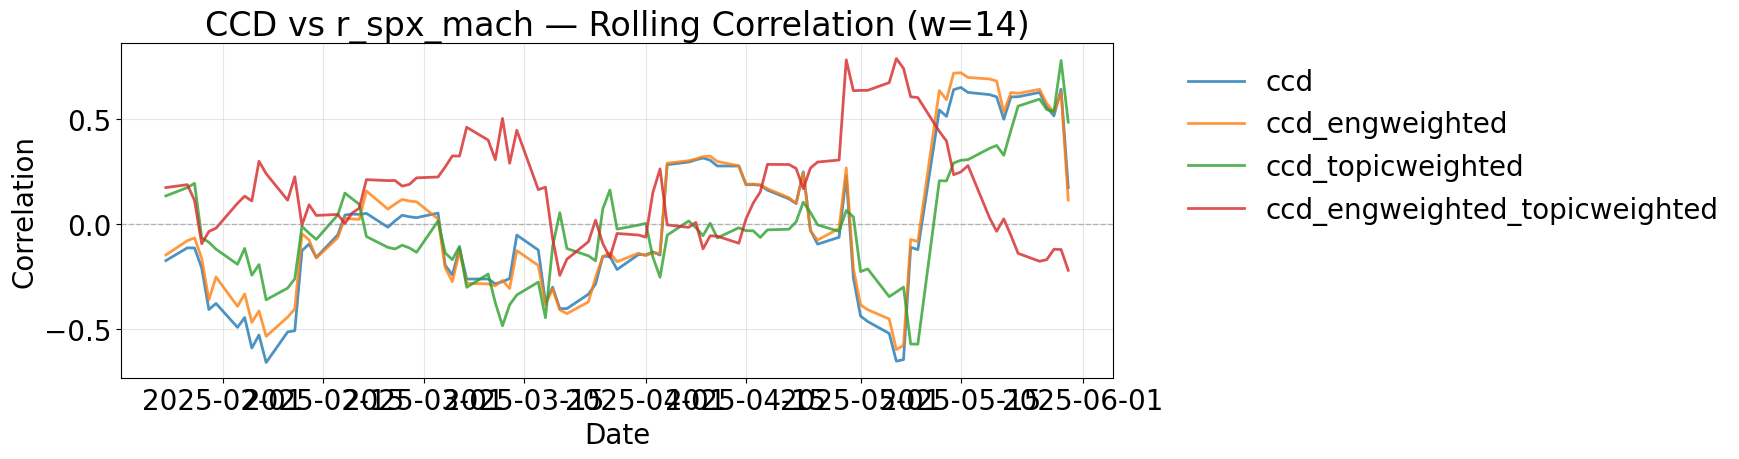

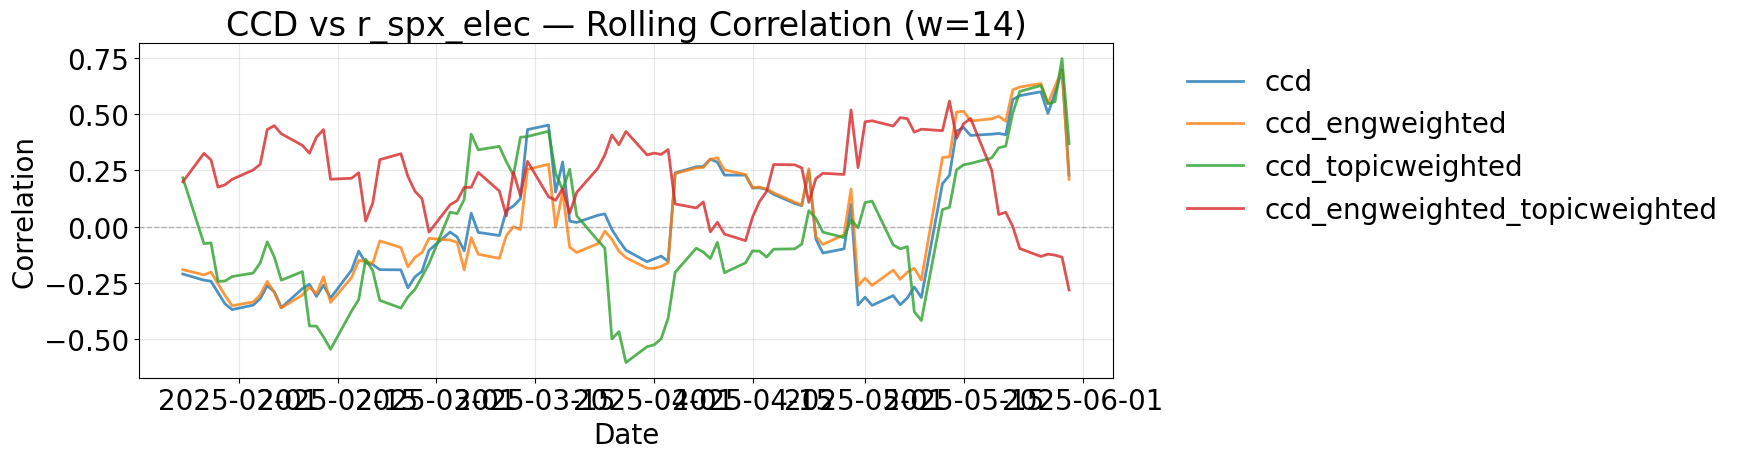

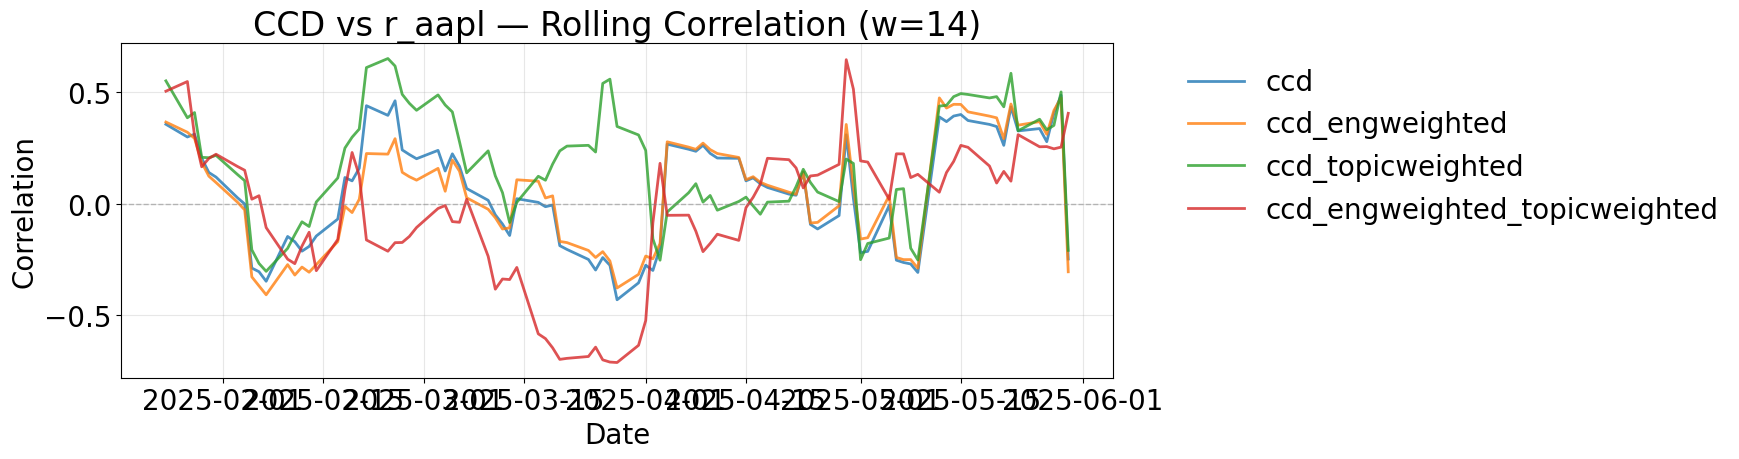

In [7]:
print("\n" + "="*70)
print("Rolling Correlations with Assets")
print("="*70)
compare_variants_vs_assets(df, ccd_variants, ASSET_COLS, 'CCD', rolling_window=ROLLING_WINDOW)

## Granger Causality Tests

Test if CCD variants Granger-cause asset returns using:
- AIC/BIC for optimal lag selection
- Benjamini-Hochberg FDR correction for multiple testing


Granger Causality Tests

GRANGER CAUSALITY TESTS: CCD Variants
Running 32 Granger causality tests...
  Index → Asset causality
  Max lag: 10, Max lead: 10, IC: AIC
  Multiple testing correction: fdr_bh

✓ Tests complete
  LAG tests - Significant relationships (corrected α=0.05): 0 of 32
  LAG tests - Uncorrected significant (α=0.05): 0
  LEAD tests - Significant relationships (corrected α=0.05): 0 of 32
  LEAD tests - Uncorrected significant (α=0.05): 1

LAG RESULTS: X(t-k) → Y(t)

P-values (at optimal lag):


asset,r_aapl,r_btc,r_gold,r_spx,r_spx_auto,r_spx_elec,r_spx_mach,r_spx_oilgas
index,,,,,,,,
ccd,0.586218,0.410674,0.067347,0.126841,0.412341,0.327844,0.663989,0.263568
ccd_engweighted,0.619608,0.431791,0.073286,0.135250,0.523584,0.280267,0.596271,0.253623
ccd_engweighted_topicweighted,0.652296,0.721854,0.088755,0.505966,0.668281,0.274794,0.216556,0.285402
ccd_topicweighted,0.315950,0.471909,0.874188,0.308208,0.595842,0.699267,0.967681,0.445749



Corrected p-values (fdr_bh):


asset,r_aapl,r_btc,r_gold,r_spx,r_spx_auto,r_spx_elec,r_spx_mach,r_spx_oilgas
index,,,,,,,,
ccd,0.763750,0.763750,0.749358,0.749358,0.76375,0.749358,0.763750,0.749358
ccd_engweighted,0.763750,0.763750,0.749358,0.749358,0.76375,0.749358,0.763750,0.749358
ccd_engweighted_topicweighted,0.763750,0.769978,0.749358,0.763750,0.76375,0.749358,0.749358,0.749358
ccd_topicweighted,0.749358,0.763750,0.902388,0.749358,0.76375,0.769978,0.967681,0.763750



Significant relationships (α=0.05, corrected):


...

asset,r_aapl,r_btc,r_gold,r_spx,r_spx_auto,r_spx_elec,r_spx_mach,r_spx_oilgas
index,,,,,,,,
ccd,0.429761,0.753924,0.503546,0.114689,0.256564,0.054684,0.354277,0.594627
ccd_engweighted,0.395076,0.745220,0.553752,0.112505,0.274785,0.102624,0.389542,0.679792
ccd_engweighted_topicweighted,0.765688,0.071609,0.016117,0.514387,0.984810,0.813922,0.401480,0.102469
ccd_topicweighted,0.328894,0.773253,0.888295,0.330812,0.313357,0.147383,0.192647,0.842517



Corrected p-values (fdr_bh):


asset,r_aapl,r_btc,r_gold,r_spx,r_spx_auto,r_spx_elec,r_spx_mach,r_spx_oilgas
index,,,,,,,,
ccd,0.723808,0.883718,0.783828,0.524291,0.713743,0.524291,0.713743,0.827308
ccd_engweighted,0.713743,0.883718,0.805457,0.524291,0.713743,0.524291,0.713743,0.883718
ccd_engweighted_topicweighted,0.883718,0.524291,0.515756,0.783828,0.984810,0.898121,0.713743,0.524291
ccd_topicweighted,0.713743,0.883718,0.916950,0.713743,0.713743,0.589534,0.684967,0.898685



Significant relationships (α=0.05, corrected):


asset,r_aapl,r_btc,r_gold,r_spx,r_spx_auto,r_spx_elec,r_spx_mach,r_spx_oilgas
index,,,,,,,,
ccd,0,0,0,0,0,0,0,0
ccd_engweighted,0,0,0,0,0,0,0,0
ccd_engweighted_topicweighted,0,0,0,0,0,0,0,0
ccd_topicweighted,0,0,0,0,0,0,0,0


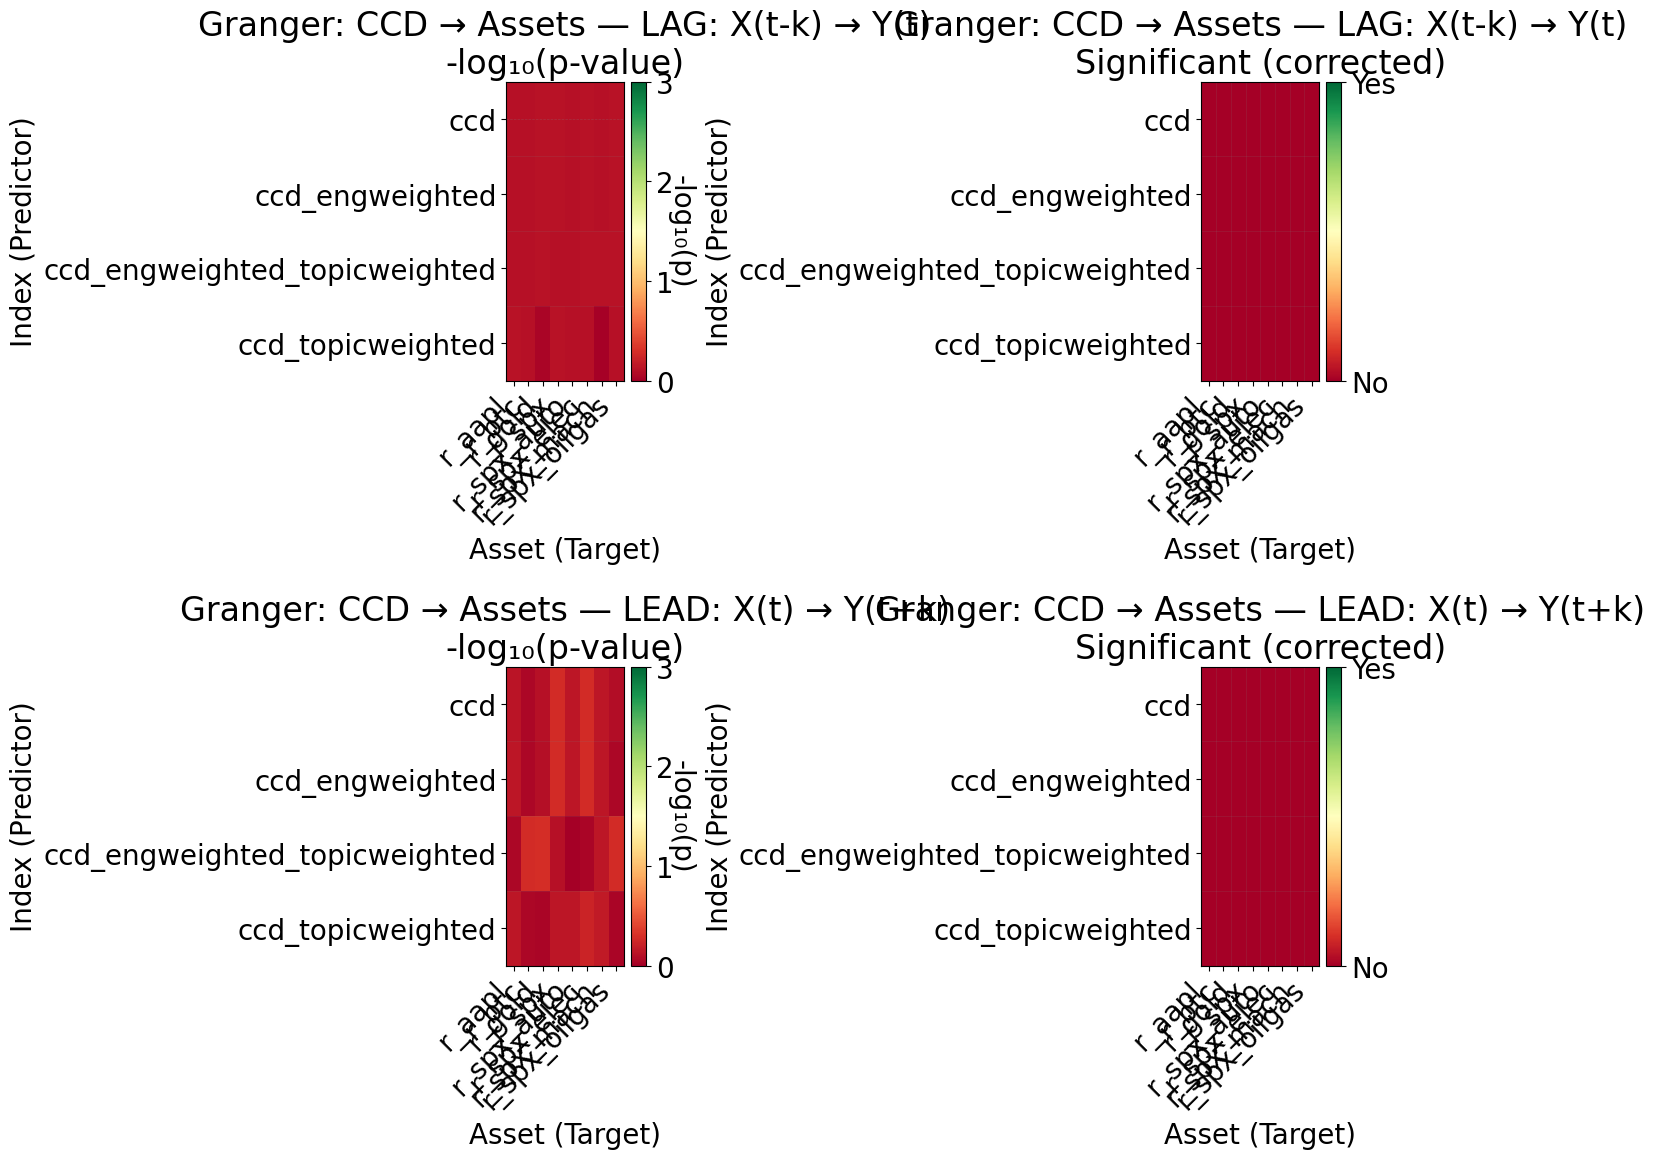

In [8]:
print("\n" + "="*70)
print("Granger Causality Tests")
print("="*70)

(pval_mat, pval_corrected, sig_mat, 
 lead_pval_mat, lead_pval_corrected, lead_sig_mat) = granger_comparison_variants(
    df, ccd_variants, ASSET_COLS,
    maxlag=MAX_LAG, ic=IC, alpha=ALPHA, correction_method=CORRECTION_METHOD
)

In [9]:
# Variant performance summary
print("\n" + "="*70)
print("Performance Summary")
print("="*70)
performance = summarize_variant_performance(
    pval_mat, sig_mat, 
    lead_pval_mat, lead_sig_mat, 
    ccd_variants
)


Performance Summary

VARIANT PERFORMANCE SUMMARY


,variant,n_significant_lags,mean_pvalue_lags,min_pvalue_lags,n_significant_leads,mean_pvalue_leads,min_pvalue_leads,total_significant
0,ccd,0,0.357353,0.067347,0,0.382759,0.054684,0
1,ccd_engweighted,0,0.364210,0.073286,0,0.406662,0.102624,0
2,ccd_topicweighted,0,0.584849,0.308208,0,0.477145,0.147383,0
3,ccd_engweighted_topicweighted,0,0.426738,0.088755,0,0.458810,0.016117,0


In [10]:
# Save results
pval_mat.to_csv(os.path.join(OUTPUT_DIR, "ccd_granger_pvalues.csv"))
pval_corrected.to_csv(os.path.join(OUTPUT_DIR, "ccd_granger_pvalues_corrected.csv"))
sig_mat.to_csv(os.path.join(OUTPUT_DIR, "ccd_granger_significant.csv"))
performance.to_csv(os.path.join(OUTPUT_DIR, "ccd_variant_performance.csv"), index=False)

print("\n✓ Results saved to:", OUTPUT_DIR)


✓ Results saved to: ./data/fm_prelim/


## Stationarity Tests

Check if series are stationary (required for valid Granger tests)

In [11]:
print("\n" + "="*70)
print("Stationarity Tests (ADF & KPSS)")
print("="*70)

stationarity_results = []

for var in ccd_variants:
    if var in df.columns:
        adf = adf_test(df[var])
        kpss_result = kpss_test(df[var])
        
        stationarity_results.append({
            'index': var,
            'adf_stat': adf['statistic'],
            'adf_pval': adf['pvalue'],
            'adf_stationary': '✓' if adf['is_stationary'] else '✗',
            'kpss_stat': kpss_result['statistic'],
            'kpss_pval': kpss_result['pvalue'],
            'kpss_stationary': '✓' if kpss_result['is_stationary'] else '✗'
        })

stationarity_df = pd.DataFrame(stationarity_results)
display(stationarity_df)

print("\nInterpretation:")
print("  ADF: H0=non-stationary. ✓ if p<0.05 (reject H0, series is stationary)")
print("  KPSS: H0=stationary. ✓ if p>0.05 (fail to reject H0, series is stationary)")


Stationarity Tests (ADF & KPSS)


/Users/briceshun/Documents/PhD 2022/youtube-emotion-financial-modelling/modules/finance/exploration/statistical_tests.py:98: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series_clean, regression=regression, nlags=nlags)
/Users/briceshun/Documents/PhD 2022/youtube-emotion-financial-modelling/modules/finance/exploration/statistical_tests.py:98: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series_clean, regression=regression, nlags=nlags)
/Users/briceshun/Documents/PhD 2022/youtube-emotion-financial-modelling/modules/finance/exploration/statistical_tests.py:98: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value ret

,index,adf_stat,adf_pval,adf_stationary,kpss_stat,kpss_pval,kpss_stationary
0,ccd,-9.702939,1.060262e-16,✓,0.143355,0.100000,✓
1,ccd_engweighted,-9.908005,3.224739e-17,✓,0.134059,0.100000,✓
2,ccd_topicweighted,-9.560281,2.436339e-16,✓,0.125771,0.100000,✓
3,ccd_engweighted_topicweighted,-8.188227,7.794329e-13,✓,0.426087,0.065911,✓



Interpretation:
  ADF: H0=non-stationary. ✓ if p<0.05 (reject H0, series is stationary)
  KPSS: H0=stationary. ✓ if p>0.05 (fail to reject H0, series is stationary)


## Bidirectional Granger Tests

Test causality in both directions for best performing variant

In [12]:
print("\n" + "="*70)
print("Bidirectional Granger Tests")
print("="*70)

# Use best performing variant
best_variant = performance.iloc[0]['variant']
print(f"\nBest variant: {best_variant}\n")

for asset in ASSET_COLS:
    print(f"\n{best_variant} ↔ {asset}:")
    print("-" * 70)
    result = bidirectional_granger_test(df, best_variant, asset, maxlag=MAX_LAG, ic=IC)
    display(result)


Bidirectional Granger Tests

Best variant: ccd


ccd ↔ r_btc:
----------------------------------------------------------------------


,direction,type,optimal_order,pvalue_at_optimal,min_pvalue,granger_causes,granger_causes_at_optimal
0,ccd → r_btc,lag,1,0.410674,0.410674,False,False
1,ccd → r_btc,lead,1,0.753924,0.160860,False,False
2,r_btc → ccd,lag,1,0.596097,0.533117,False,False
3,r_btc → ccd,lead,3,0.379728,0.114960,False,False



ccd ↔ r_gold:
----------------------------------------------------------------------


,direction,type,optimal_order,pvalue_at_optimal,min_pvalue,granger_causes,granger_causes_at_optimal
0,ccd → r_gold,lag,1,0.067347,0.045319,True,False
1,ccd → r_gold,lead,1,0.503546,0.051535,False,False
2,r_gold → ccd,lag,1,0.317208,0.077464,False,False
3,r_gold → ccd,lead,3,0.008368,0.008368,True,True



ccd ↔ r_spx:
----------------------------------------------------------------------


...

,direction,type,optimal_order,pvalue_at_optimal,min_pvalue,granger_causes,granger_causes_at_optimal
0,ccd → r_spx_mach,lag,1,0.663989,0.269588,False,False
1,ccd → r_spx_mach,lead,1,0.354277,0.101924,False,False
2,r_spx_mach → ccd,lag,1,0.009601,0.009601,True,True
3,r_spx_mach → ccd,lead,3,0.274393,0.140472,False,False



ccd ↔ r_spx_elec:
----------------------------------------------------------------------


,direction,type,optimal_order,pvalue_at_optimal,min_pvalue,granger_causes,granger_causes_at_optimal
0,ccd → r_spx_elec,lag,1,0.327844,0.076802,False,False
1,ccd → r_spx_elec,lead,1,0.054684,0.054684,False,False
2,r_spx_elec → ccd,lag,1,0.002731,0.002731,True,True
3,r_spx_elec → ccd,lead,3,0.167697,0.137357,False,False



ccd ↔ r_aapl:
----------------------------------------------------------------------


,direction,type,optimal_order,pvalue_at_optimal,min_pvalue,granger_causes,granger_causes_at_optimal
0,ccd → r_aapl,lag,1,0.586218,0.343792,False,False
1,ccd → r_aapl,lead,1,0.429761,0.130490,False,False
2,r_aapl → ccd,lag,1,0.015885,0.015885,True,True
3,r_aapl → ccd,lead,3,0.239943,0.101500,False,False


## Event Window Analysis

How do CCD variants behave during major tariff events?

In [13]:
EVENT_WINDOWS = [
    ("Initial Tariff Announcements", "2025-01-20", "2025-01-26"),
    ("Tariffs Postponed", "2025-03-04", "2025-03-06"),
    ("China Retaliation & US Tariffs", "2025-03-10", "2025-03-13"),
    ("Global Tariffs", "2025-04-02", "2025-04-06"),
    ("US-China Tariff Threats", "2025-04-09", "2025-04-12"),
    ("Tariffs Relaxed", "2025-04-27", "2025-05-04"),
    ("Trade Deals", "2025-05-05", "2025-05-14"),
    ("Apple Tariff Threat", "2025-05-20", "2025-05-25"),
]

print("\n" + "="*70)
print("Event Window Analysis")
print("="*70)

event_comparison = event_window_comparison(df, ccd_variants, EVENT_WINDOWS, pre_days=7, post_days=7)

# Display delta rows only (more compact)
delta_rows = event_comparison[event_comparison['phase'].str.contains('Δ', na=False)]
display(delta_rows)

# Save
event_comparison.to_csv(os.path.join(OUTPUT_DIR, "ccd_event_windows.csv"), index=False)
print("\n✓ Event analysis saved")


Event Window Analysis


,event,phase,n,ccd_mean,ccd_std,ccd_engweighted_mean,ccd_engweighted_std,ccd_topicweighted_mean,ccd_topicweighted_std,ccd_engweighted_topicweighted_mean,ccd_engweighted_topicweighted_std
3,Initial Tariff Announcements,Δ during-pre,NaN,-0.086027,NaN,-0.073127,NaN,-0.060123,NaN,0.029067,NaN
4,Initial Tariff Announcements,Δ post-during,NaN,0.107160,NaN,0.088755,NaN,0.011735,NaN,-0.019022,NaN
8,Tariffs Postponed,Δ during-pre,NaN,-0.058629,NaN,-0.052134,NaN,-0.046050,NaN,0.052477,NaN
9,Tariffs Postponed,Δ post-during,NaN,-0.004456,NaN,-0.007152,NaN,-0.011594,NaN,-0.046600,NaN
13,China Retaliation & US Tariffs,Δ during-pre,NaN,-0.024098,NaN,-0.007854,NaN,0.011943,NaN,-0.070036,NaN
14,China Retaliation & US Tariffs,Δ post-during,NaN,0.098663,NaN,0.090497,NaN,-0.078136,NaN,0.102385,NaN
18,Global Tariffs,Δ during-pre,NaN,0.146474,NaN,0.135979,NaN,0.059601,NaN,-0.058813,NaN
19,Global Tariffs,Δ post-during,NaN,-0.060285,NaN,-0.054773,NaN,0.037580,NaN,0.057744,NaN
23,US-China Tariff Threats,Δ during-pre,NaN,0.073783,NaN,0.072011,NaN,0.082586,NaN,0.096273,NaN
24,US-China Tariff Threats,Δ post-during,NaN,-0.069132,NaN,-0.067011,NaN,-0.138757,NaN,-0.154416,NaN



✓ Event analysis saved


## Summary

Comprehensive comparison of CCD variants

In [14]:
print("\n" + "="*70)
print("CCD VARIANT COMPARISON - SUMMARY")
print("="*70)

print("\n1. VARIANTS TESTED:")
for i, var in enumerate(ccd_variants, 1):
    print(f"   {i}. {var}")

print("\n2. CORRELATION WITH ASSETS (mean absolute):")
for var in ccd_variants:
    if var in df.columns:
        mean_abs_corr = df[[var] + ASSET_COLS].corr().loc[var, ASSET_COLS].abs().mean()
        print(f"   {var:40s}: {mean_abs_corr:.4f}")

print("\n3. GRANGER CAUSALITY (significant relationships after FDR):")
for _, row in performance.iterrows():
    print(f"   {row['variant']:40s}: Lags: {int(row['n_significant_lags'])}, Leads: {int(row['n_significant_leads'])}, Total: {int(row['total_significant'])}")

print("\n4. BEST PERFORMING VARIANT:")
print(f"   {best_variant}")
print(f"   - Significant Granger relationships (lags): {int(performance.iloc[0]['n_significant_lags'])}/{len(ASSET_COLS)}")
print(f"   - Significant Granger relationships (leads): {int(performance.iloc[0]['n_significant_leads'])}/{len(ASSET_COLS)}")
print(f"   - Mean p-value (lags): {performance.iloc[0]['mean_pvalue_lags']:.4f}")

print("\n5. KEY INSIGHTS:")
print(f"   - CCD captures information asymmetry between creators and community")
print(f"   - High divergence may signal informed vs uninformed trading")
print(f"   - Potentially useful for detecting sentiment manipulation")
print(f"   - Lead tests help identify predictive vs reactive relationships")

print("\n" + "="*70)
print("✓ CCD ANALYSIS COMPLETE")
print("="*70)


CCD VARIANT COMPARISON - SUMMARY

1. VARIANTS TESTED:
   1. ccd
   2. ccd_engweighted
   3. ccd_topicweighted
   4. ccd_engweighted_topicweighted

2. CORRELATION WITH ASSETS (mean absolute):
   ccd                                     : 0.1059
   ccd_engweighted                         : 0.1096
   ccd_topicweighted                       : 0.0688
   ccd_engweighted_topicweighted           : 0.0926

3. GRANGER CAUSALITY (significant relationships after FDR):
   ccd                                     : Lags: 0, Leads: 0, Total: 0
   ccd_engweighted                         : Lags: 0, Leads: 0, Total: 0
   ccd_topicweighted                       : Lags: 0, Leads: 0, Total: 0
   ccd_engweighted_topicweighted           : Lags: 0, Leads: 0, Total: 0

4. BEST PERFORMING VARIANT:
   ccd
   - Significant Granger relationships (lags): 0/8
   - Significant Granger relationships (leads): 0/8
   - Mean p-value (lags): 0.3574

5. KEY INSIGHTS:
   - CCD captures information asymmetry between creators 